# Notebook 01 — Mô hình Baseline: TF-IDF + Naive Bayes & SVM

**Mục tiêu:** Xây dựng các mô hình học máy truyền thống làm đường cơ sở (Baseline) để đối chuẩn với các mô hình học sâu:
- Trích xuất đặc trưng bằng **TF-IDF** (ngram 1–2, max 5000 từ)
- Huấn luyện **Multinomial Naive Bayes**
- Huấn luyện **Linear SVM (LinearSVC)**
- Đánh giá qua Accuracy, Precision, Recall, F1-Score
- Lưu mô hình để tái sử dụng và vẽ Ma trận nhầm lẫn

> **Yêu cầu tiên quyết:** Phải chạy xong `00_Tien_Xu_Ly.ipynb` trước để có dữ liệu trong thư mục `fn/`.

In [ ]:
# ===== CÀI ĐẶT THƯ VIỆN =====
!pip install pandas scikit-learn matplotlib seaborn joblib


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

FN_DIR  = "../fn"
PKL_DIR = "../pkl"
IMG_DIR = "../image"
os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

print(" Import thư viện thành công!")


 Import thư viện thành công!


## 1. Nạp Dữ liệu Đã Tiền xử lý

In [2]:
train_df = pd.read_csv(os.path.join(FN_DIR, "cleaned_train.csv")).fillna('')
test_df  = pd.read_csv(os.path.join(FN_DIR, "cleaned_test.csv")).fillna('')

X_train, y_train = train_df['comment_cleaned'], train_df['label']
X_test,  y_test  = test_df['comment_cleaned'],  test_df['label']

print(f"Tập Train : {len(X_train):,} mẫu")
print(f"Tập Test  : {len(X_test):,} mẫu")
print(f"Phân bố nhãn (Train): {dict(y_train.value_counts().sort_index())}")


Tập Train : 11,426 mẫu
Tập Test  : 3,166 mẫu
Phân bố nhãn (Train): {0: np.int64(5325), 1: np.int64(458), 2: np.int64(5643)}


## 2. Trích xuất Đặc trưng TF-IDF

In [3]:
print("Đang trích xuất đặc trưng TF-IDF...")

# max_features=5000: Giữ lại 5000 từ/cụm từ quan trọng nhất
# ngram_range=(1,2): Sử dụng cả unigram và bigram
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)   # Học từ vựng từ tập Train
X_test_tfidf  = tfidf.transform(X_test)         # Chỉ biến đổi (không học) tập Test

# Lưu vectorizer để dùng ở bước Predict
joblib.dump(tfidf, os.path.join(PKL_DIR, "tfidf_vectorizer.pkl"))

print(f"Kích thước ma trận Train: {X_train_tfidf.shape}")
print(f"Kích thước ma trận Test : {X_test_tfidf.shape}")
print(f"Đã lưu TfidfVectorizer → {PKL_DIR}/tfidf_vectorizer.pkl")


Đang trích xuất đặc trưng TF-IDF...
Kích thước ma trận Train: (11426, 5000)
Kích thước ma trận Test : (3166, 5000)
Đã lưu TfidfVectorizer → ../pkl/tfidf_vectorizer.pkl


## 3. Huấn luyện Mô hình Naive Bayes

In [5]:
print("Đang huấn luyện Multinomial Naive Bayes...")

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_acc  = accuracy_score(y_test, nb_pred)

joblib.dump(nb_model, os.path.join(PKL_DIR, "naive_bayes_model.pkl"))

print(f"Test Accuracy: {nb_acc*100:.2f}%")
print(f"Đã lưu mô hình → {PKL_DIR}/naive_bayes_model.pkl")
print()
label_names = ['Tieu cuc (0)', 'Trung tinh (1)', 'Tich cuc (2)']
print(classification_report(y_test, nb_pred, target_names=label_names, digits=4))


Đang huấn luyện Multinomial Naive Bayes...
Test Accuracy: 86.42%
Đã lưu mô hình → ../pkl/naive_bayes_model.pkl

                precision    recall  f1-score   support

  Tieu cuc (0)     0.8159    0.9532    0.8792      1409
Trung tinh (1)     0.5000    0.0120    0.0234       167
  Tich cuc (2)     0.9175    0.8748    0.8957      1590

      accuracy                         0.8642      3166
     macro avg     0.7445    0.6133    0.5994      3166
  weighted avg     0.8503    0.8642    0.8423      3166



## 4. Huấn luyện Mô hình SVM

In [6]:
print("Đang huấn luyện Linear SVM (LinearSVC)...")

# C=0.1: Hệ số chính quy hóa; dual=False: Phù hợp khi số mẫu > số đặc trưng
svm_model = LinearSVC(C=0.1, max_iter=2000, random_state=42, dual=False)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_acc  = accuracy_score(y_test, svm_pred)

joblib.dump(svm_model, os.path.join(PKL_DIR, "svm_best_model.pkl"))

print(f"Test Accuracy: {svm_acc*100:.2f}%")
print(f"Đã lưu mô hình → {PKL_DIR}/svm_best_model.pkl")
print()
print(classification_report(y_test, svm_pred, target_names=label_names, digits=4))


Đang huấn luyện Linear SVM (LinearSVC)...
Test Accuracy: 88.69%
Đã lưu mô hình → ../pkl/svm_best_model.pkl

                precision    recall  f1-score   support

  Tieu cuc (0)     0.8552    0.9638    0.9062      1409
Trung tinh (1)     0.6000    0.0539    0.0989       167
  Tich cuc (2)     0.9219    0.9063    0.9141      1590

      accuracy                         0.8869      3166
     macro avg     0.7924    0.6413    0.6397      3166
  weighted avg     0.8752    0.8869    0.8676      3166



## 5. Vẽ Ma trận Nhầm lẫn (Confusion Matrix)

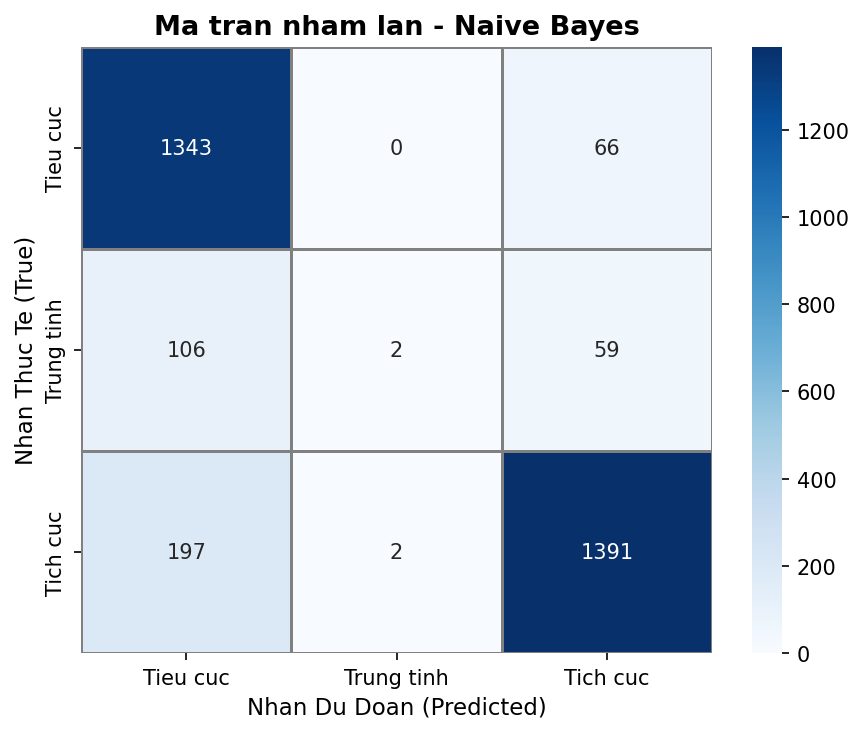

Đã lưu ảnh → ../image/cm_naive_bayes.png


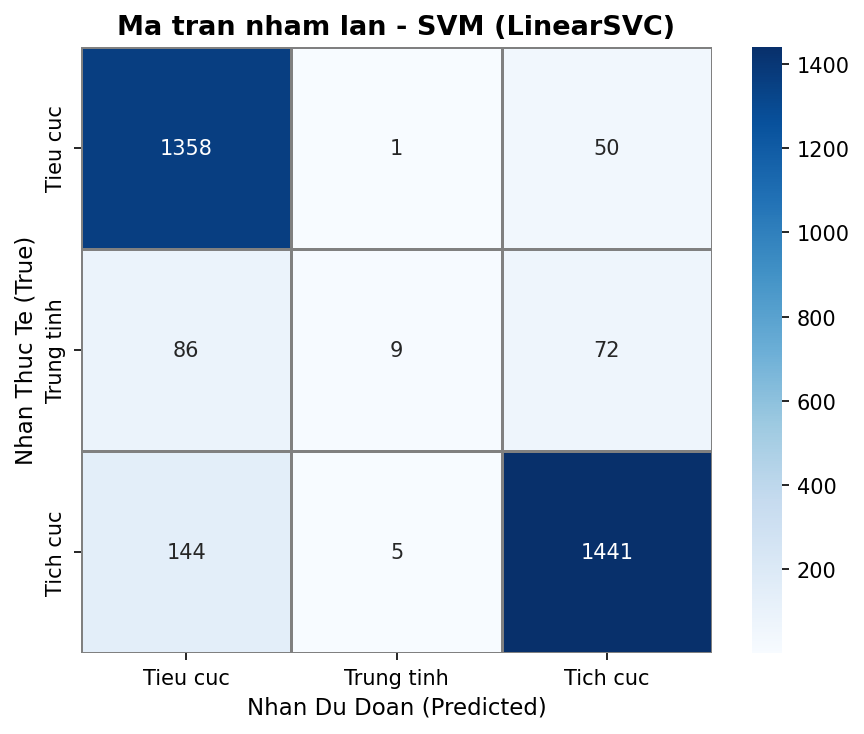

Đã lưu ảnh → ../image/cm_svm.png


In [7]:
def plot_cm(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)
    class_names = ['Tieu cuc', 'Trung tinh', 'Tich cuc']
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray')
    plt.xlabel('Nhan Du Doan (Predicted)', fontsize=11)
    plt.ylabel('Nhan Thuc Te (True)', fontsize=11)
    plt.title(f'Ma tran nham lan - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(IMG_DIR, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Đã lưu ảnh → {save_path}")

plot_cm(y_test, nb_pred,  "Naive Bayes",   "cm_naive_bayes.png")
plot_cm(y_test, svm_pred, "SVM (LinearSVC)","cm_svm.png")


## 6. Tổng hợp Kết quả Baseline

In [8]:
print("=" * 55)
print(f"{'Mô hình':<25} {'Accuracy':>10} {'F1-Macro':>10}")
print("-" * 55)
from sklearn.metrics import f1_score
print(f"{'Multinomial Naive Bayes':<25} {nb_acc*100:>9.2f}% {f1_score(y_test,nb_pred,average='macro')*100:>9.2f}%")
print(f"{'Linear SVM (LinearSVC)':<25} {svm_acc*100:>9.2f}% {f1_score(y_test,svm_pred,average='macro')*100:>9.2f}%")
print("=" * 55)


Mô hình                     Accuracy   F1-Macro
-------------------------------------------------------
Multinomial Naive Bayes       86.42%     59.94%
Linear SVM (LinearSVC)        88.69%     63.97%
